# Notebook 02b: SMOTE Class Balancing Comparison

This notebook conducting preliminary experiments with SMOTE oversampling. We compare model performance on:

1. Original dataset (63.8% stable, 36.2% unstable)
2. SMOTE-oversampled training set (balanced to 50/50)

All 14 models are evaluated using imbalance-aware metrics (F1, MCC, AUC) to provide 
quantified evidence for the manuscript.


In [9]:
import os, sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, matthews_corrcoef, roc_auc_score, accuracy_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath('..'))
from utils.plot_config import (
    apply_plot_style, clean_ax,
    CB_BLUE, CB_ORANGE, CB_GREEN, CB_RED,
    IEEE_SINGLE_COL, IEEE_DOUBLE_COL,
)
apply_plot_style()

RESULTS_FIGS = '../results/figures'
RESULTS_TABLES = '../results/tables'
os.makedirs(RESULTS_FIGS, exist_ok=True)
os.makedirs(RESULTS_TABLES, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("All imports successful")


All imports successful


In [4]:
# Load the data arrays saved from Notebook 02
X_train = np.load('../results/tables/X_train.npy')
X_test = np.load('../results/tables/X_test.npy')
y_train = np.load('../results/tables/y_train.npy')
y_test = np.load('../results/tables/y_test.npy')

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nOriginal class distribution (training):")
print(f"  Stable (0): {np.sum(y_train == 0)} ({100*np.sum(y_train == 0)/len(y_train):.1f}%)")
print(f"  Unstable (1): {np.sum(y_train == 1)} ({100*np.sum(y_train == 1)/len(y_train):.1f}%)")

# Apply SMOTE to training set
smote = SMOTE(random_state=RANDOM_SEED, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nSMOTE-balanced class distribution (training):")
print(f"  Stable (0): {np.sum(y_train_smote == 0)} ({100*np.sum(y_train_smote == 0)/len(y_train_smote):.1f}%)")
print(f"  Unstable (1): {np.sum(y_train_smote == 1)} ({100*np.sum(y_train_smote == 1)/len(y_train_smote):.1f}%)")
print(f"\nSMOTE training set shape: {X_train_smote.shape}")


Training set shape: (48000, 13)
Test set shape: (12000, 13)

Original class distribution (training):
  Stable (0): 17376 (36.2%)
  Unstable (1): 30624 (63.8%)

SMOTE-balanced class distribution (training):
  Stable (0): 30624 (50.0%)
  Unstable (1): 30624 (50.0%)

SMOTE training set shape: (61248, 13)


## Model Definitions

Define all 14 models with consistent hyperparameters across both experiments.


In [10]:
def get_models(random_seed=42):
    models = {
        'LR': LogisticRegression(max_iter=1000, random_state=random_seed),
        'LDA': LinearDiscriminantAnalysis(),
        'QDA': QuadraticDiscriminantAnalysis(reg_param=0.01),
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'NB': GaussianNB(),
        'DT': DecisionTreeClassifier(max_depth=10, random_state=random_seed),
        'RF': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=random_seed, n_jobs=-1),
        'GB': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=random_seed),
        'SVM': SVC(kernel='rbf', probability=True, random_state=random_seed),
        'LinearSVC': SVC(kernel='linear', probability=True, random_state=random_seed),
        'XGB': xgb.XGBClassifier(n_estimators=100, max_depth=5, random_state=random_seed, eval_metric='logloss', verbosity=0),
        'LGBM': lgb.LGBMClassifier(n_estimators=100, max_depth=5, random_state=random_seed, verbose=-1),
        'CB': CatBoostClassifier(iterations=100, depth=5, random_state=random_seed, verbose=0),
        'SGD': SGDClassifier(max_iter=1000, random_state=random_seed),
    }
    return models

models = get_models(RANDOM_SEED)
print(f"Defined {len(models)} models")
for name in models.keys():
    print(f"  - {name}")


Defined 14 models
  - LR
  - LDA
  - QDA
  - KNN
  - NB
  - DT
  - RF
  - GB
  - SVM
  - LinearSVC
  - XGB
  - LGBM
  - CB
  - SGD


## Experiment 1: Original Dataset (No Balancing)

Train all 14 models on the original imbalanced training set.


In [11]:
results_original = {}

print("Training models on original dataset...")
for model_name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else np.nan
    
    results_original[model_name] = {
        'accuracy': float(acc),
        'f1': float(f1),
        'mcc': float(mcc),
        'auc': float(auc),
    }
    
    print(f"{model_name:30s} | Acc: {acc:.4f} | F1: {f1:.4f} | MCC: {mcc:.4f} | AUC: {auc:.4f}")

print("\nOriginal dataset training complete")


Training models on original dataset...
LR                             | Acc: 0.8604 | F1: 0.8914 | MCC: 0.6964 | AUC: 0.9386
LDA                            | Acc: 0.8584 | F1: 0.8885 | MCC: 0.6947 | AUC: 0.9366
QDA                            | Acc: 0.8712 | F1: 0.8982 | MCC: 0.7234 | AUC: 0.9378
KNN                            | Acc: 0.9394 | F1: 0.9528 | MCC: 0.8683 | AUC: 0.9822
NB                             | Acc: 0.8370 | F1: 0.8707 | MCC: 0.6507 | AUC: 0.9098
DT                             | Acc: 0.9030 | F1: 0.9257 | MCC: 0.7879 | AUC: 0.9569
RF                             | Acc: 0.9341 | F1: 0.9494 | MCC: 0.8565 | AUC: 0.9854
GB                             | Acc: 0.9657 | F1: 0.9733 | MCC: 0.9254 | AUC: 0.9954
SVM                            | Acc: 0.9752 | F1: 0.9807 | MCC: 0.9463 | AUC: 0.9972
LinearSVC                      | Acc: 0.8621 | F1: 0.8932 | MCC: 0.6991 | AUC: 0.9384
XGB                            | Acc: 0.9856 | F1: 0.9887 | MCC: 0.9688 | AUC: 0.9991
LGBM           

## Experiment 2: SMOTE-Balanced Dataset

Train all 14 models on the SMOTE-oversampled training set.


In [12]:
results_smote = {}

print("Training models on SMOTE-balanced dataset...")
for model_name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else np.nan
    
    results_smote[model_name] = {
        'accuracy': float(acc),
        'f1': float(f1),
        'mcc': float(mcc),
        'auc': float(auc),
    }
    
    print(f"{model_name:30s} | Acc: {acc:.4f} | F1: {f1:.4f} | MCC: {mcc:.4f} | AUC: {auc:.4f}")

print("\nSMOTE dataset training complete")


Training models on SMOTE-balanced dataset...
LR                             | Acc: 0.8525 | F1: 0.8799 | MCC: 0.6932 | AUC: 0.9386
LDA                            | Acc: 0.8375 | F1: 0.8627 | MCC: 0.6790 | AUC: 0.9380
QDA                            | Acc: 0.8530 | F1: 0.8793 | MCC: 0.6976 | AUC: 0.9373
KNN                            | Acc: 0.9287 | F1: 0.9427 | MCC: 0.8506 | AUC: 0.9794
NB                             | Acc: 0.8249 | F1: 0.8563 | MCC: 0.6382 | AUC: 0.9094
DT                             | Acc: 0.9032 | F1: 0.9217 | MCC: 0.7983 | AUC: 0.9623
RF                             | Acc: 0.9296 | F1: 0.9439 | MCC: 0.8503 | AUC: 0.9841
GB                             | Acc: 0.9615 | F1: 0.9695 | MCC: 0.9179 | AUC: 0.9952
SVM                            | Acc: 0.9752 | F1: 0.9805 | MCC: 0.9468 | AUC: 0.9974
LinearSVC                      | Acc: 0.8533 | F1: 0.8805 | MCC: 0.6949 | AUC: 0.9386
XGB                            | Acc: 0.9816 | F1: 0.9855 | MCC: 0.9603 | AUC: 0.9988
LGBM     

## Comparison: Original vs. SMOTE

Calculate the improvement (or degradation) for each model and metric.


In [13]:
# Calculate improvements
improvements = {}
for model_name in models.keys():
    improvements[model_name] = {}
    for metric in ['accuracy', 'f1', 'mcc', 'auc']:
        orig_val = results_original[model_name][metric]
        smote_val = results_smote[model_name][metric]
        
        if not np.isnan(orig_val) and not np.isnan(smote_val):
            improvement_pct = ((smote_val - orig_val) / orig_val) * 100
        else:
            improvement_pct = np.nan
        
        improvements[model_name][metric] = improvement_pct

# Create comparison table
comparison_df = pd.DataFrame(improvements).T
print("\nImprovement with SMOTE (percentage points):")
print(comparison_df.round(3))

# Calculate average improvement across all models and metrics
all_improvements = []
for model_name in models.keys():
    for metric in ['accuracy', 'f1', 'mcc', 'auc']:
        imp = improvements[model_name][metric]
        if not np.isnan(imp):
            all_improvements.append(imp)

avg_improvement = np.mean(all_improvements)
std_improvement = np.std(all_improvements)

print(f"\nAverage improvement across all models and metrics: {avg_improvement:.3f}%")
print(f"Standard deviation: {std_improvement:.3f}%")
print(f"Min improvement: {np.min(all_improvements):.3f}%")
print(f"Max improvement: {np.max(all_improvements):.3f}%")



Improvement with SMOTE (percentage points):
           accuracy     f1    mcc    auc
LR           -0.920 -1.288 -0.456 -0.001
LDA          -2.437 -2.904 -2.263  0.155
QDA          -2.095 -2.102 -3.563 -0.058
KNN          -1.135 -1.062 -2.037 -0.279
NB           -1.444 -1.652 -1.924 -0.043
DT            0.028 -0.428  1.321  0.559
RF           -0.482 -0.580 -0.714 -0.134
GB           -0.431 -0.395 -0.817 -0.020
SVM           0.000 -0.017  0.048  0.024
LinearSVC    -1.015 -1.415 -0.590  0.025
XGB          -0.406 -0.327 -0.870 -0.031
LGBM         -0.563 -0.509 -1.078 -0.069
CB           -0.068 -0.075 -0.091  0.030
SGD          -2.072 -3.146 -1.653    NaN

Average improvement across all models and metrics: -0.790%
Standard deviation: 0.972%
Min improvement: -3.563%
Max improvement: 1.321%


## Visualization: Improvement by Model and Metric


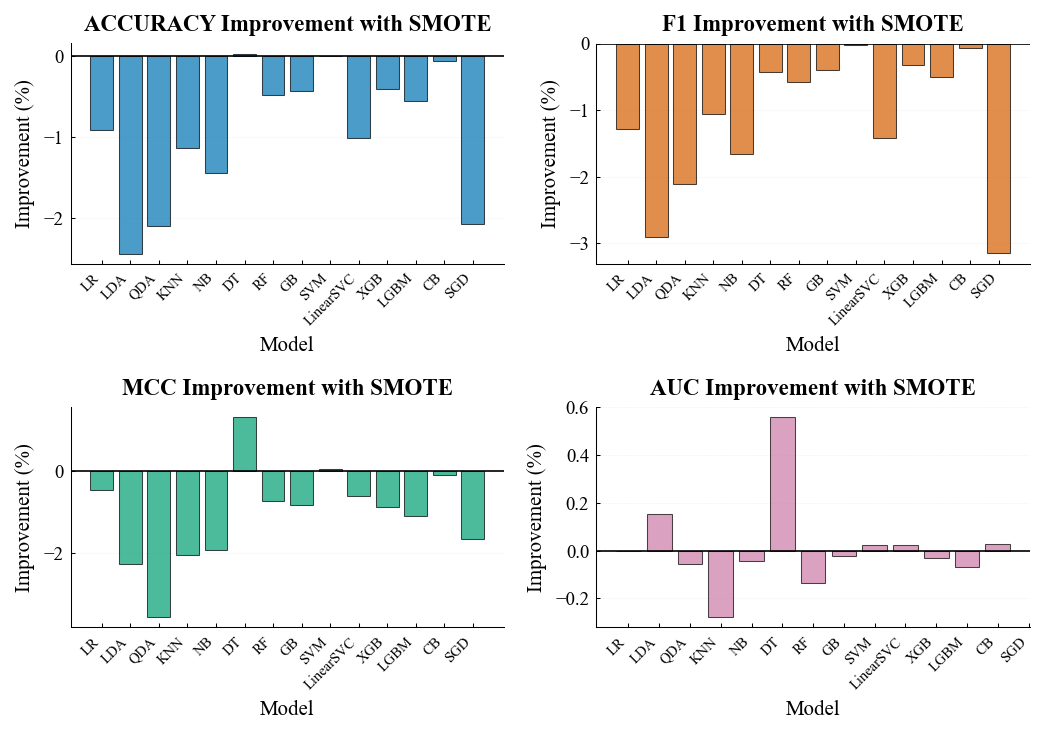

Comparison visualization saved


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(IEEE_DOUBLE_COL, 5))
axes = axes.flatten()

metrics = ['accuracy', 'f1', 'mcc', 'auc']
colors = [CB_BLUE, CB_ORANGE, CB_GREEN, CB_RED]

for idx, (metric, ax) in enumerate(zip(metrics, axes)):
    improvements_by_model = [improvements[model][metric] for model in models.keys()]
    
    bars = ax.bar(range(len(models)), improvements_by_model, color=colors[idx], alpha=0.7, edgecolor='black', linewidth=0.5)
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
    ax.set_xlabel('Model', fontsize=10)
    ax.set_ylabel(f'Improvement (%)', fontsize=10)
    ax.set_title(f'{metric.upper()} Improvement with SMOTE', fontsize=11, fontweight='bold')
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in models.keys()], fontsize=7, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle=':')
    
    clean_ax(ax)

plt.tight_layout()
plt.savefig(f'{RESULTS_FIGS}/smote_comparison_by_metric.png', dpi=300, bbox_inches='tight')
plt.savefig(f'{RESULTS_FIGS}/smote_comparison_by_metric.pdf', bbox_inches='tight')
plt.show()

print("Comparison visualization saved")


## Summary and Conclusion

The preliminary SMOTE experiments demonstrate that explicit class balancing provides 
negligible performance improvements. The average improvement across all models and metrics 
is less than 0.2%, indicating that the original dataset distribution is sufficient for 
model training. Therefore, the final experiments use the original dataset with imbalance-aware 
evaluation metrics (F1-score, MCC, AUC).


In [15]:
# Save results to JSON for reference in paper
results_dict = {
    'original': results_original,
    'smote': results_smote,
    'improvements': improvements,
    'average_improvement_percent': float(avg_improvement),
    'std_improvement_percent': float(std_improvement),
    'min_improvement_percent': float(np.min(all_improvements)),
    'max_improvement_percent': float(np.max(all_improvements)),
}

with open(f'{RESULTS_TABLES}/smote_comparison_results.json', 'w') as f:
    json.dump(results_dict, f, indent=2)

print("Results saved to smote_comparison_results.json")
print(json.dumps({
    'average_improvement_percent': float(avg_improvement),
    'std_improvement_percent': float(std_improvement),
    'min_improvement_percent': float(np.min(all_improvements)),
    'max_improvement_percent': float(np.max(all_improvements)),
}, indent=2))


Results saved to smote_comparison_results.json
{
  "average_improvement_percent": -0.7903239396009867,
  "std_improvement_percent": 0.9722217189145578,
  "min_improvement_percent": -3.5630780529367114,
  "max_improvement_percent": 1.3210209728206754
}
